# Merchant Churn Predictive Prototype: Quick-Commerce Analytics

**Business Objective:** Shift platform churn management from reactive to proactive. By predicting which merchants will leave the platform in the next 3 months, account managers can intervene, protecting a projected ~12% in annual platform revenue across regional markets.

## Tech Stack
* **Data Manipulation:** Python (Pandas, NumPy)
* **Exploratory Querying:** SQL (SQLite3)
* **Predictive Modeling:** Machine Learning (Scikit-Learn Random Forest)
* **Data Visualization:** Matplotlib, Seaborn

In [11]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set seed for reproducibility
np.random.seed(42)
n_samples = 1000

# Generate base features
df = pd.DataFrame(
    {
        "restaurant_id": [f"REST_{i:04d}" for i in range(n_samples)],
        "total_orders": np.random.randint(10, 1500, size=n_samples),
        "avg_rating": np.random.uniform(2.0, 5.0, size=n_samples),
        "avg_delivery_time_mins": np.random.randint(15, 60, size=n_samples),
        "customer_complaints": np.random.randint(0, 50, size=n_samples),
        "monthly_revenue": np.random.uniform(1000, 25000, size=n_samples),
    }
)
print(f"Successfully generated base features for {len(df)} merchants.")

Successfully generated base features for 1000 merchants.


In [12]:
# Create weighted base risk
churn_risk = (
    (df["total_orders"] < 200).astype(int) * 1.5
    + (df["avg_rating"] < 3.5).astype(int) * 1.2
    + (df["avg_delivery_time_mins"] > 40).astype(int) * 1.0
    + (df["customer_complaints"] > 20).astype(int) * 1.3
)

# Introduce noise to simulate messy real-world market behavior
noise = np.random.normal(0, 1.2, size=n_samples)

df["churned"] = ((churn_risk + noise) > 3.5).astype(int)

# Save dataframe down to a physical CSV file
df.to_csv("restaurant_churn_data.csv", index=False)
print(f"Target labels generated with realistic noise. Dataset saved to CSV.")
print(f"Actual Churn Rate: {(df['churned'].mean() * 100):.1f}%")

Target labels generated with realistic noise. Dataset saved to CSV.
Actual Churn Rate: 17.3%


In [13]:
# Load the saved CSV file to ensure clean separation of steps
df_sql = pd.read_csv("restaurant_churn_data.csv")
conn = sqlite3.connect(":memory:")
df_sql.to_sql("restaurants", conn, index=False, if_exists="replace")

print("--- SQL REPORT: CHURNED VS RETAINED ---")
query_1 = """
SELECT
    churned,
    COUNT(*) as count,
    ROUND(AVG(total_orders), 0) as avg_orders,
    ROUND(AVG(avg_rating), 2) as avg_rating
FROM restaurants GROUP BY churned;
"""
print(pd.read_sql(query_1, conn).to_string(index=False))

print("\n--- SQL REPORT: REVENUE AT RISK BY DELIVERY BUCKET ---")

query_2 = """
SELECT
    CASE
        WHEN avg_delivery_time_mins < 30 THEN 'Fast (<30 min)'
        WHEN avg_delivery_time_mins < 45 THEN 'Average (30-45 min)'
        ELSE 'Slow (>45 min)'
    END as delivery_bucket,
    COUNT(*) as merchant_count,
    ROUND(SUM(CASE WHEN churned=1 THEN monthly_revenue ELSE 0 END), 2) as revenue_at_risk,
    ROUND(AVG(CASE WHEN churned=1 THEN 1.0 ELSE 0 END)*100, 1) as churn_rate_pct
FROM restaurants
GROUP BY delivery_bucket
ORDER BY revenue_at_risk DESC;
"""
print(pd.read_sql(query_2, conn).to_string(index=False))

--- SQL REPORT: CHURNED VS RETAINED ---
 churned  count  avg_orders  avg_rating
       0    827       819.0        3.59
       1    173       600.0        3.13

--- SQL REPORT: REVENUE AT RISK BY DELIVERY BUCKET ---
    delivery_bucket  merchant_count  revenue_at_risk  churn_rate_pct
     Slow (>45 min)             326       1162791.97            27.0
Average (30-45 min)             357        657728.81            14.6
     Fast (<30 min)             317        380412.12            10.4


In [14]:
# Isolate feature metrics from metadata
X = df.drop(columns=["restaurant_id", "churned"])
y = df["churned"]

# Split features and labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data uniformly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

# Calculate model performance metrics
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
print(f"ROC-AUC Performance Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

ROC-AUC Performance Score: 0.752


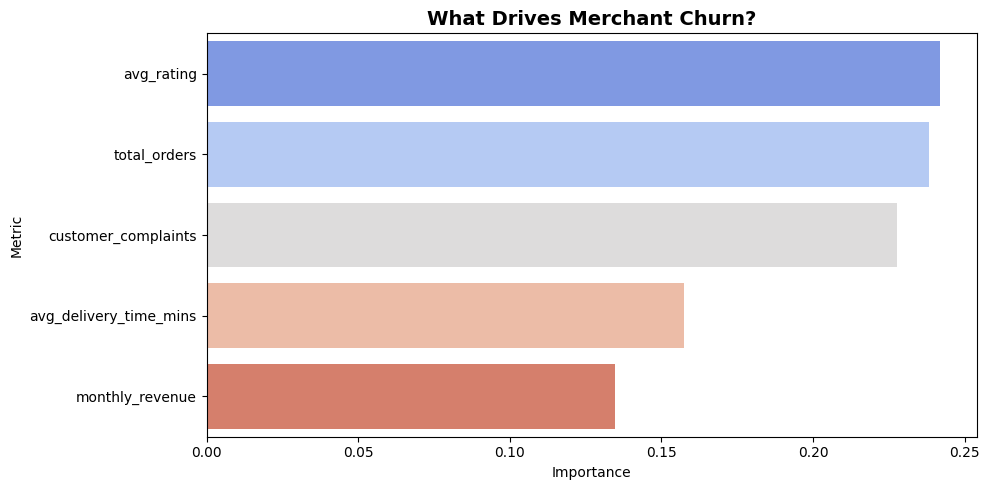

In [15]:
# Construct and organize feature importance map
feature_importance = pd.DataFrame(
    {"Metric": X.columns, "Importance": model.feature_importances_}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Metric",
    hue="Metric",
    palette="coolwarm",
    legend=False,
)
plt.title("What Drives Merchant Churn?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

In [16]:
# Create a deployment mapping function for business interventions
def assign_intervention_tier(probability):
    if probability > 0.70:
        return "Tier 1: High Risk - Manual Account Manager Outreach (48h)"
    elif probability >= 0.50:
        return "Tier 2: Medium Risk - Trigger 30-Day Automated Commission Discount"
    else:
        return "Tier 3: Stable - Standard Automated Engagement Loops"

# Assemble data tracking frame for the validation split
crm_routing_df = pd.DataFrame({
    "restaurant_id": df.loc[X_test.index, "restaurant_id"],
    "monthly_revenue": df.loc[X_test.index, "monthly_revenue"],
    "churn_probability": y_pred_proba
})

# Route records into operational categories
crm_routing_df["action_required"] = crm_routing_df["churn_probability"].apply(assign_intervention_tier)

# Isolate priority alerts (High-revenue accounts needing manual outreach)
priority_alerts = crm_routing_df[crm_routing_df["action_required"].str.startswith("Tier 1")].sort_values("monthly_revenue", ascending=False)

print("="*70)
print(" CRM PIPELINE ACTION QUEUE: TOP 5 HIGH-VALUE PRIORITY RETENTION ALERTS ")
print("="*70)
print(priority_alerts.head(5).to_string(index=False))

 CRM PIPELINE ACTION QUEUE: TOP 5 HIGH-VALUE PRIORITY RETENTION ALERTS 
restaurant_id  monthly_revenue  churn_probability                                           action_required
    REST_0947     16034.968472           0.701551 Tier 1: High Risk - Manual Account Manager Outreach (48h)
    REST_0280     14944.362241           0.902334 Tier 1: High Risk - Manual Account Manager Outreach (48h)
    REST_0256     11811.485715           0.831750 Tier 1: High Risk - Manual Account Manager Outreach (48h)
    REST_0292      9327.103834           0.704591 Tier 1: High Risk - Manual Account Manager Outreach (48h)
